# Whipsaw: block sells for N days after a buy

A momentum signal that sits near its threshold flips in and out: it pays the fee on every
flip and sells dips that recover. This notebook tests a simple fix: after a buy, ignore
sell signals for `N` days. It compares hold lengths on BTC under three momentum
thresholds, checks the result at other lookbacks, and renders a video of one rule on BTC,
LINK and DOGE. The lookback and thresholds were chosen by a grid search on the BTC history.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from algo_trading.backtest import backtest as bt, data, plots, signals
from algo_trading.backtest.config import FEE_BPS, PortfolioConfig

plots.apply_theme()

SYMBOL = "btc"                 # token ids are lowercase
LOOKBACK = 26                                          # momentum window, in days
PAIRS = [(0.0, -0.01), (0.0, -0.02), (0.0, -0.03)]     # (buy, sell) momentum thresholds
HOLD_DAYS = [0, 4, 8, 16]      # sells blocked for N days after each buy; 0 = no filter
WHIPSAW_DAYS = 7               # a round trip shorter than this counts as a whipsaw
WARMUP = LOOKBACK              # first bar with a momentum value
FEE = FEE_BPS                  # 0.2% per fill; whipsaw pays it twice per flip
INITIAL = 10_000
CFG = PortfolioConfig(check_bars=1, rebalance=False)   # all in on a buy, all out on a sell
COLORS = plots.ramp(len(HOLD_DAYS))

## Data

In [2]:
panel = data.daily_panel([SYMBOL])
close = panel.close
print(panel.describe())

1,096 1d bars x 1 tokens  2023-01-01 00:00:00+00:00 -> 2025-12-31 00:00:00+00:00


## Signals

In [3]:
def pair_label(buy: float, sell: float) -> str:
    return f"buy >{buy:+.0%}, sell <{sell:+.0%}"


RULES = {pair_label(b, s): signals.momentum_thresholds(close, LOOKBACK, b, s)[:2]
         for b, s in PAIRS}
mom = signals.momentum(close, LOOKBACK)


def held(enter: pd.DataFrame, exit_: pd.DataFrame, hold: int, start: int) -> pd.DataFrame:
    """100% in SYMBOL while the rule is on; exits ignored for `hold` days after a buy.

    No entries before `start`, so the hold clock never starts before trading does."""
    live = enter & (np.arange(len(enter)) >= start)[:, None]
    return bt.slot_weights(live, 1, exit=exit_, min_hold=hold)


def position(rule: str, hold: int) -> pd.DataFrame:
    return held(*RULES[rule], hold, WARMUP)


def hold_label(hold: int) -> str:
    return "no hold" if hold == 0 else f"{hold}d hold"

## Whipsaw on the price chart

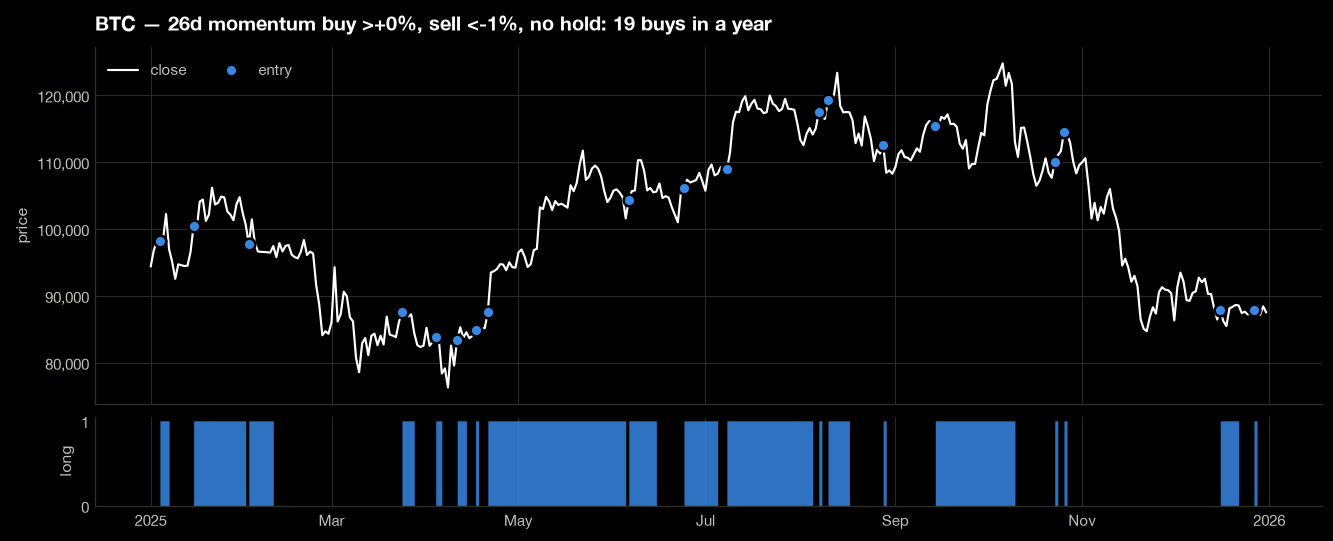

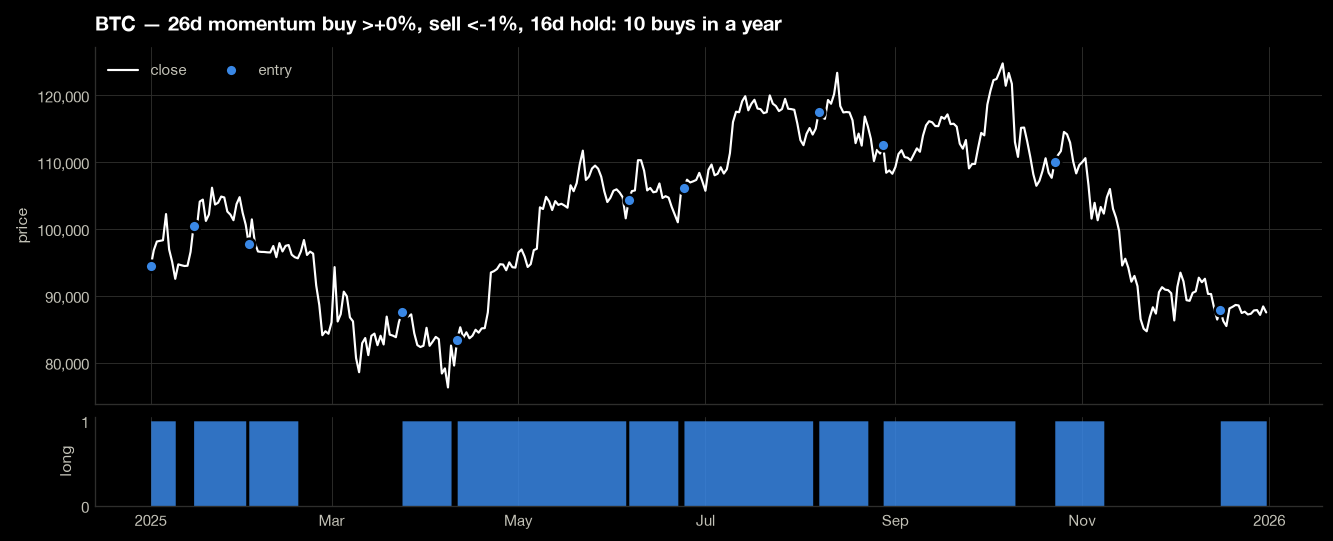

In [4]:
ZOOM, RULE0 = len(close) - 365, pair_label(*PAIRS[0])
for hold in (0, HOLD_DAYS[-1]):
    pos = position(RULE0, hold)[SYMBOL]
    fig, axes = plots.price_signal(close[SYMBOL], pos, SYMBOL, start=ZOOM, figsize=(11, 4.4))
    n_buys = int((pos.iloc[ZOOM:].diff() > 0).sum())
    axes[0].set_title(f"{SYMBOL.upper()} — {LOOKBACK}d momentum {RULE0}, {hold_label(hold)}: "
                      f"{n_buys} buys in a year")
    plt.show()

## Backtest

In [5]:
def fee_drag(n_fills: int) -> float:
    """Share of the account consumed by fees; exact when every fill is all in or all out."""
    return 1 - (1 - FEE / 1e4) ** n_fills


def round_trips(res: dict) -> pd.DataFrame:
    """Pair each BUY fill with the SELL that closes it (one symbol, all in / all out)."""
    f = res["fills"]
    buys, sells = f[f.side == "BUY"].reset_index(drop=True), f[f.side == "SELL"].reset_index(drop=True)
    n = len(sells)                                 # a still-open last buy is left out
    return pd.DataFrame({"days": (sells.ts - buys.ts[:n]).dt.days,
                         "ret": (sells.notional - sells.fee) / buys.notional[:n] - 1})


runs, rows = {}, []
for rule in RULES:
    results = bt.simulate_many(close, [position(rule, h) for h in HOLD_DAYS], CFG,
                               fee_bps=FEE, initial=INITIAL, warmup=WARMUP)
    for hold, res in zip(HOLD_DAYS, results):
        trips = round_trips(res)
        short = trips[trips.days < WHIPSAW_DAYS]         # the whipsaws
        # all in / all out, so growth is the product of trip returns; whipsaw_drag is the
        # part of it from the short trips alone, fees included
        row = bt.stats_from_result(res, f"{rule}, {hold_label(hold)}", WARMUP,
                                   panel.bars_per_year)
        row |= {"final_$": res["equity"].iloc[-1], "fee_drag": fee_drag(len(res["fills"])),
                "trips": len(trips),
                "whipsaws": len(short), "whipsaw_drag": (1 + short.ret).prod() - 1,
                "avg_days": trips.days.mean()}
        runs[rule, hold], rows = res, rows + [row]

bh = close[SYMBOL] / close[SYMBOL].iloc[WARMUP] * INITIAL
bench = bt.perf(bh, f"{SYMBOL.upper()} buy & hold", start=WARMUP, initial=INITIAL,
                bars_per_year=panel.bars_per_year) | {"final_$": bh.iloc[-1]}

table = pd.DataFrame(rows + [bench]).set_index("label")
bt.fmt_table(table[["final_$", "total_ret", "sharpe", "max_dd", "n_fills", "fee_drag", "trips",
                    "whipsaws", "whipsaw_drag", "avg_days"]],
             {**bt.PERF_FMT, "final_$": "${:,.0f}", "fee_drag": "{:.0%}", "trips": "{:.0f}", "whipsaws": "{:.0f}",
              "whipsaw_drag": "{:+.1%}", "avg_days": "{:.1f}"})

,final_$,total_ret,sharpe,max_dd,n_fills,fee_drag,trips,whipsaws,whipsaw_drag,avg_days
label,,,,,,,,,,
"buy >+0%, sell <-1%, no hold","$23,308",+133.1%,0.98,-32.4%,94,17%,47,28,-37.3%,13.4
"buy >+0%, sell <-1%, 4d hold","$29,669",+196.7%,1.18,-36.6%,75,14%,37,17,-26.0%,18.1
"buy >+0%, sell <-1%, 8d hold","$39,710",+297.1%,1.40,-32.4%,71,13%,35,0,+0.0%,20.7
"buy >+0%, sell <-1%, 16d hold","$44,066",+340.7%,1.46,-29.2%,49,9%,24,0,+0.0%,33.1
"buy >+0%, sell <-2%, no hold","$26,948",+169.5%,1.11,-28.8%,86,16%,43,26,-30.7%,15.0
"buy >+0%, sell <-2%, 4d hold","$33,798",+238.0%,1.30,-31.3%,69,13%,34,16,-19.4%,19.9
"buy >+0%, sell <-2%, 8d hold","$43,867",+338.7%,1.49,-30.0%,65,12%,32,0,+0.0%,22.8
"buy >+0%, sell <-2%, 16d hold","$50,400",+404.0%,1.57,-24.4%,45,9%,22,0,+0.0%,35.9
"buy >+0%, sell <-3%, no hold","$32,546",+225.5%,1.27,-28.5%,68,13%,34,18,-23.4%,19.9


## Equity

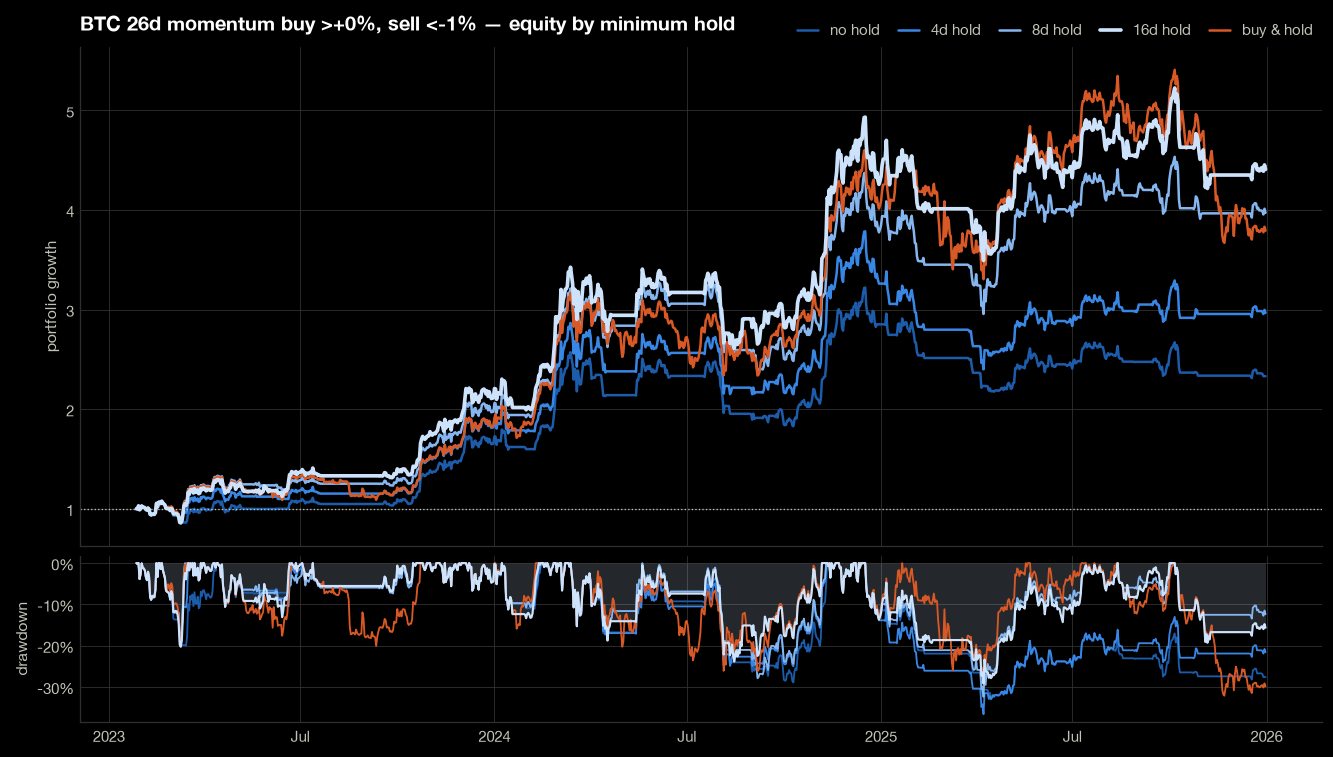

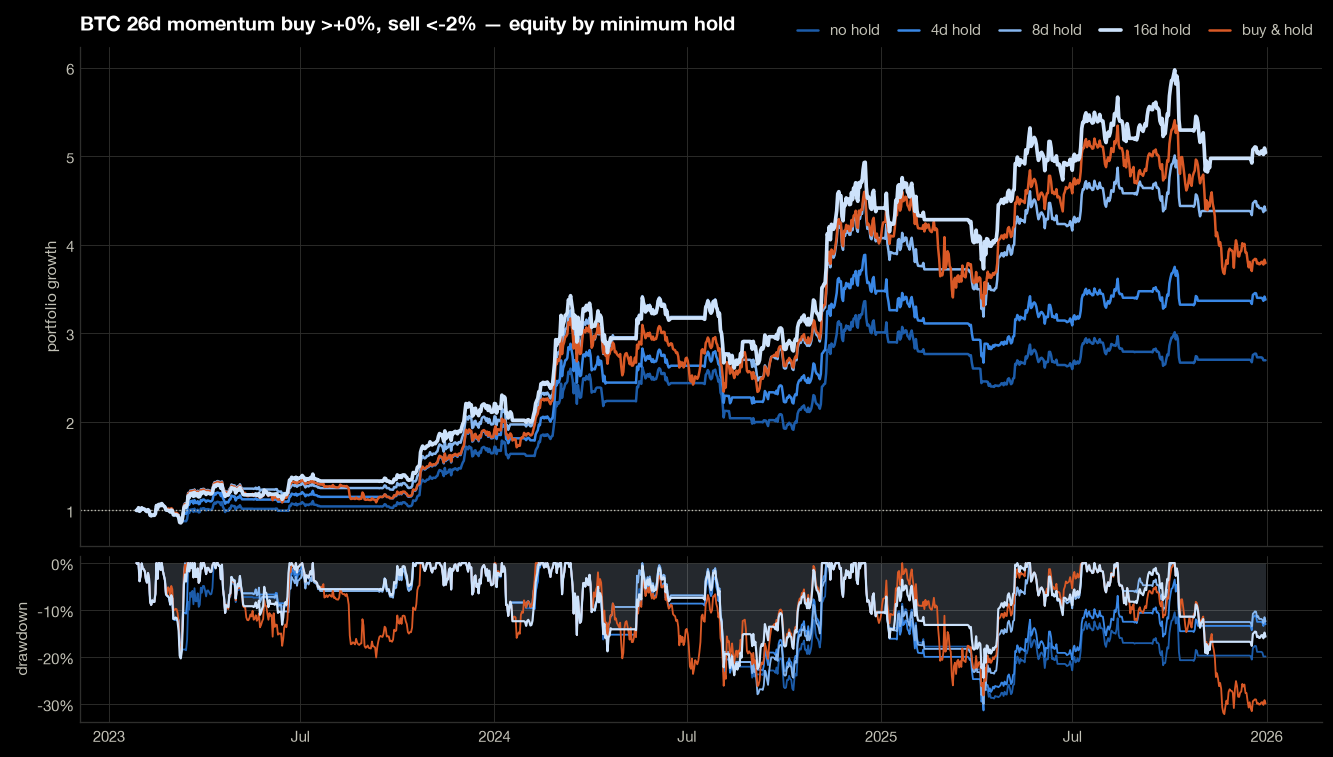

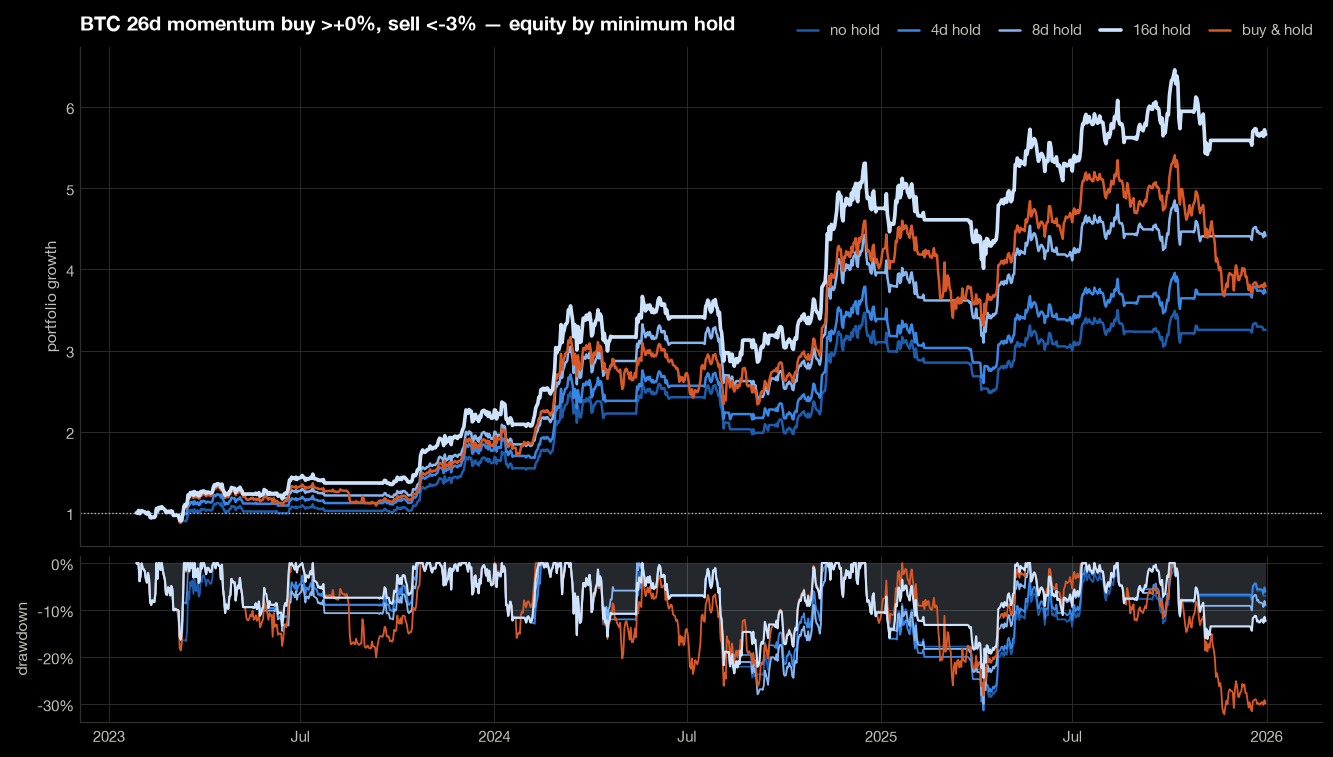

In [6]:
for rule in RULES:
    curves = {hold_label(h): runs[rule, h]["equity"].iloc[WARMUP:] for h in HOLD_DAYS}
    curves["buy & hold"] = bh.iloc[WARMUP:]
    plots.equity_drawdown(curves, f"{SYMBOL.upper()} {LOOKBACK}d momentum {rule} — "
                                  "equity by minimum hold",
                          colors=[*COLORS, plots.color(1)], dd_for=hold_label(HOLD_DAYS[-1]))
    plt.show()

## Round-trip length

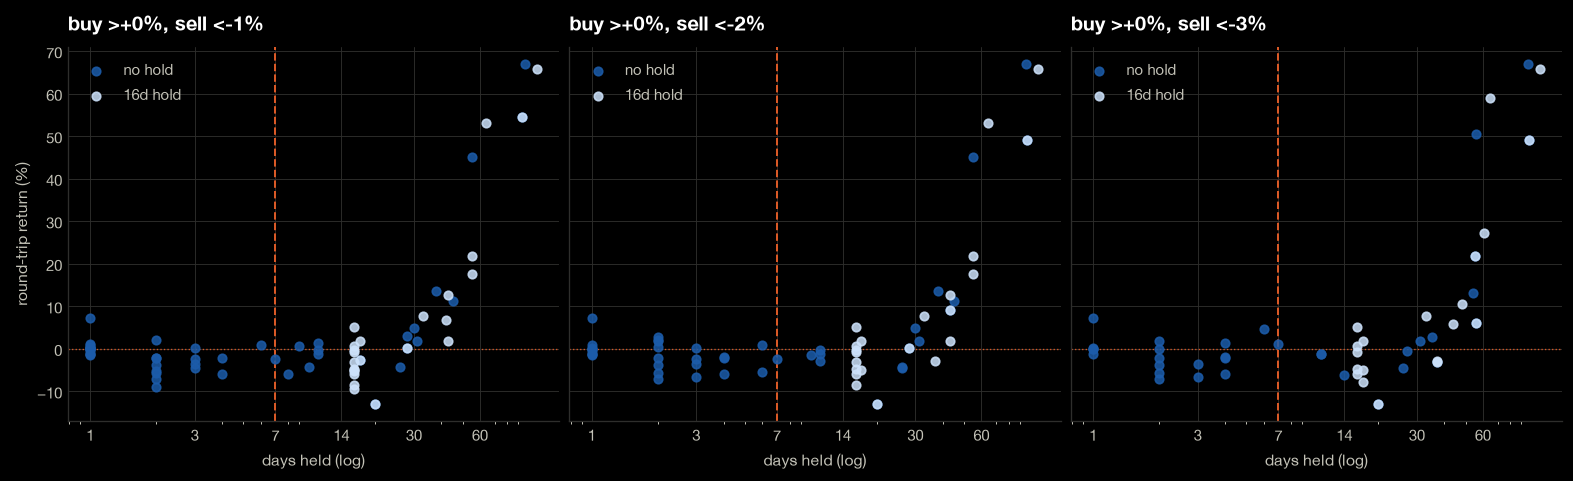

In [7]:
fig, axes = plt.subplots(1, len(RULES), figsize=(13, 3.9), layout="constrained", sharey=True)
for ax, rule in zip(axes, RULES):
    for i, hold in enumerate((HOLD_DAYS[0], HOLD_DAYS[-1])):
        trips = round_trips(runs[rule, hold])
        ax.scatter(trips.days, trips.ret * 100, s=26, alpha=0.85,
                   color=COLORS[0 if i == 0 else -1], label=hold_label(hold), zorder=3)
    ax.axvline(WHIPSAW_DAYS, color=plots.color(1), ls="--", lw=1.2)
    ax.axhline(0, color=plots.color(1), lw=0.8, ls=":")
    ax.set_xscale("log")
    ax.set_xticks([1, 3, 7, 14, 30, 60], ["1", "3", "7", "14", "30", "60"])
    ax.xaxis.set_minor_formatter("")
    ax.set_title(rule)
    ax.set_xlabel("days held (log)")
    ax.legend(loc="upper left")
axes[0].set_ylabel("round-trip return (%)")
plt.show()

## Return, trades and fees vs hold length

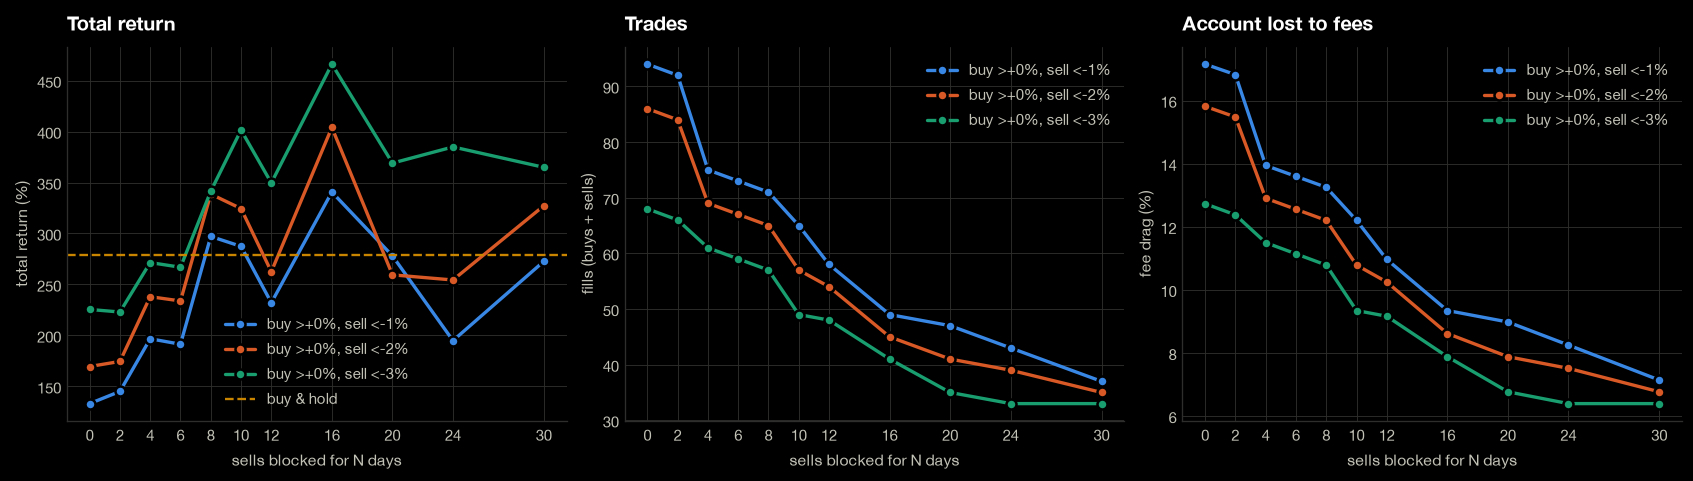

In [8]:
SWEEP = [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 30]

sweep = {}
for rule in RULES:
    results = bt.simulate_many(close, [position(rule, h) for h in SWEEP], CFG,
                               fee_bps=FEE, initial=INITIAL, warmup=WARMUP)
    sweep[rule] = {"ret": [r["equity"].iloc[-1] / r["equity"].iloc[WARMUP] * 100 - 100
                           for r in results],
                   "fills": [len(r["fills"]) for r in results],
                   "fees": [fee_drag(len(r["fills"])) * 100 for r in results]}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9), layout="constrained")
plots.sweep(SWEEP, {r: s["ret"] for r, s in sweep.items()}, "Total return",
            "sells blocked for N days", "total return (%)",
            hlines={"buy & hold": bench["total_ret"] * 100}, ax=axes[0])
plots.sweep(SWEEP, {r: s["fills"] for r, s in sweep.items()}, "Trades",
            "sells blocked for N days", "fills (buys + sells)", ax=axes[1])
plots.sweep(SWEEP, {r: s["fees"] for r, s in sweep.items()}, "Account lost to fees",
            "sells blocked for N days", "fee drag (%)", ax=axes[2])
for ax in axes:
    ax.set_xticks(SWEEP)
plt.show()

## Hold gain by lookback

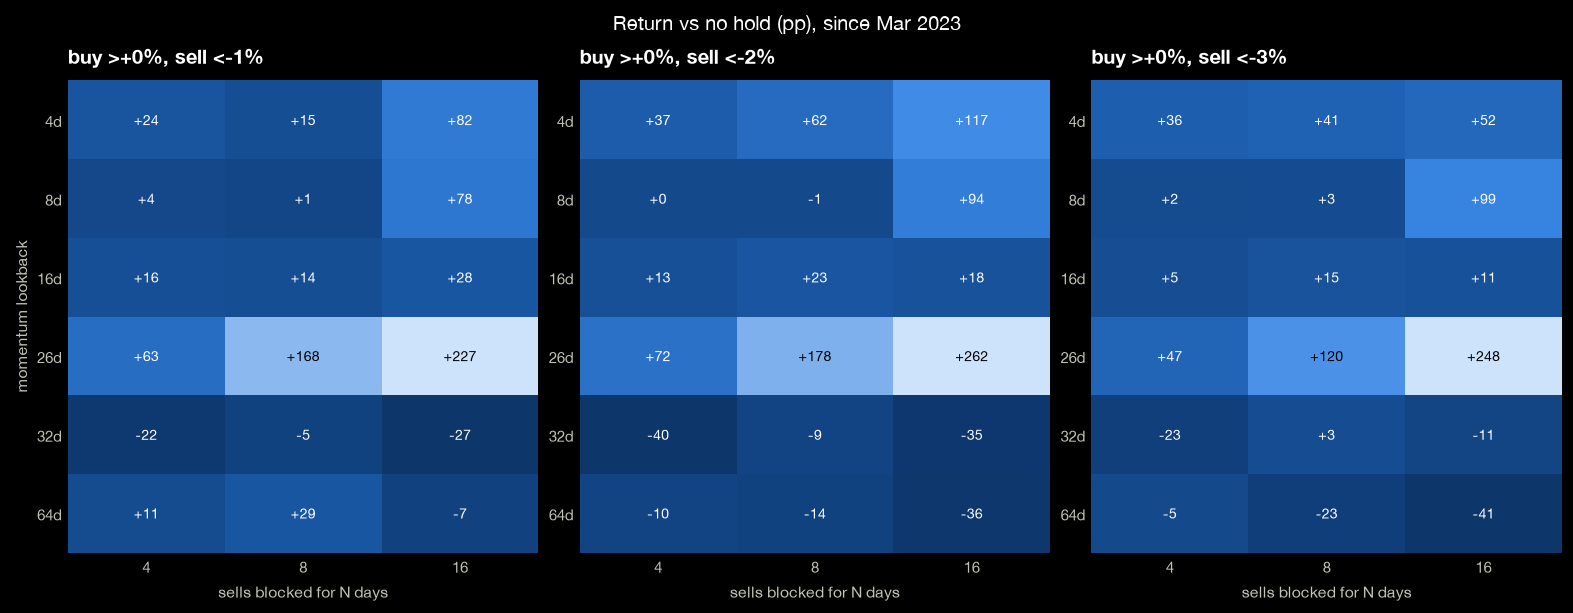

hold helped in 70% of 54 cells; median change +15pp
  buy >+0%, sell <-1%: helped in 78%, median +15pp
  buy >+0%, sell <-2%: helped in 61%, median +15pp
  buy >+0%, sell <-3%: helped in 72%, median +8pp


In [9]:
LOOKBACKS = [4, 8, 16, 26, 32, 64]
GRID_HOLDS = [0, *HOLD_DAYS[1:]]
GRID_WARMUP = max(LOOKBACKS)   # common scoring window for every lookback


def gain_surface(buy: float, sell: float) -> pd.DataFrame:
    grid = {}
    for lb in LOOKBACKS:
        en, ex, _ = signals.momentum_thresholds(close, lb, buy, sell)
        results = bt.simulate_many(close, [held(en, ex, h, GRID_WARMUP) for h in GRID_HOLDS],
                                   CFG, fee_bps=FEE, initial=INITIAL, warmup=GRID_WARMUP)
        grid[f"{lb}d"] = [(r["equity"].iloc[-1] / r["equity"].iloc[GRID_WARMUP] - 1) * 100
                          for r in results]
    surface = pd.DataFrame(grid, index=GRID_HOLDS).T
    return surface.sub(surface[0], axis=0).drop(columns=0)


grids = {pair_label(b, s): gain_surface(b, s) for b, s in PAIRS}

since = close.index[GRID_WARMUP].strftime("%b %Y")
fig, axes = plt.subplots(1, len(grids), figsize=(13, 5), layout="constrained")
for ax, (rule, g) in zip(axes, grids.items()):
    plots.heatmap(g, rule, fmt="{:+.0f}", xlabel="sells blocked for N days",
                  ylabel="momentum lookback" if ax is axes[0] else "", ax=ax)
fig.suptitle(f"Return vs no hold (pp), since {since}")
plt.show()

cells = pd.concat([g.stack() for g in grids.values()])
print(f"hold helped in {(cells > 0).mean():.0%} of {len(cells)} cells; "
      f"median change {cells.median():+.0f}pp")
for rule, g in grids.items():
    c = g.stack()
    print(f"  {rule}: helped in {(c > 0).mean():.0%}, median {c.median():+.0f}pp")

## Video: BTC, LINK and DOGE

In [10]:
import os
import tempfile
from pathlib import Path

from IPython.display import Video

from algo_trading.backtest import animate
from algo_trading.backtest.config import PROJECT_ROOT

BRAND = PROJECT_ROOT.parent / "public"   # local brand assets; not part of this repo
FONT = BRAND / "fonts" / "alliance-no1" / "Degarism Studio - Alliance No.1 Light.otf"
ICON = BRAND / "hpt-icon-purple.svg"

VIDEO_SYMBOLS = ["btc", "link", "doge"]
VIDEO_PAIR = PAIRS[-1]                     # buy >0%, sell <-3%
video_close = data.daily_panel(VIDEO_SYMBOLS).close

summary, parts = {}, []
with tempfile.TemporaryDirectory() as tmp:
    for k, sym in enumerate(VIDEO_SYMBOLS, 1):
        px = video_close[[sym]].dropna()
        enter, exit_, _ = signals.momentum_thresholds(px, LOOKBACK, *VIDEO_PAIR)
        results = bt.simulate_many(px, [held(enter, exit_, h, WARMUP) for h in HOLD_DAYS], CFG,
                                   fee_bps=FEE, initial=INITIAL, warmup=WARMUP)
        curves = {hold_label(h): r["equity"].iloc[WARMUP:] for h, r in zip(HOLD_DAYS, results)}
        final = {lab: e.iloc[-1] / e.iloc[0] - 1 for lab, e in curves.items()}
        fills = {hold_label(h): len(r["fills"]) for h, r in zip(HOLD_DAYS, results)}
        best = max(final, key=final.get)
        sym_bh = px[sym].iloc[-1] / px[sym].iloc[WARMUP] - 1
        summary[sym.upper()] = {**{lab: f"{final[lab]:+.0%} ({fills[lab]} fills)" for lab in final},
                                "buy & hold": f"{sym_bh:+.0%}"}
        curves["buy & hold"] = px[sym].iloc[WARMUP:]
        parts.append(animate.equity_race(
            curves, Path(tmp) / f"part{k}.mp4",
            title="Wait before you sell?",
            subtitle=f"{sym.upper()} · {pair_label(*VIDEO_PAIR)} · "
                     f"{LOOKBACK}d momentum · {FEE / 100:g}% fee",
            caption=f"{best}: {final[best]:+.0%}, {fills[best]} trades. "
                    f"Buy & hold: {sym_bh:+.0%}.",
            colors=[*plots.ramp(len(HOLD_DAYS), hue="purple"), plots.color(1)],
            dd_for=hold_label(HOLD_DAYS[-1]),
            font=FONT if FONT.exists() else None, icon=ICON if ICON.exists() else None,
            progress=False))
    video = animate.concat(parts, PROJECT_ROOT / ".media" / "whipsaw.mp4")

print(pd.DataFrame(summary).rename_axis(pair_label(*VIDEO_PAIR)).to_string())
Video(os.path.relpath(video), embed=False, width=540)

                                  BTC              LINK              DOGE
buy >+0%, sell <-3%                                                      
no hold              +225% (68 fills)  +100% (86 fills)  +171% (50 fills)
4d hold              +271% (61 fills)   +75% (77 fills)  +200% (44 fills)
8d hold              +341% (57 fills)  +141% (61 fills)  +250% (38 fills)
16d hold             +466% (41 fills)  +132% (45 fills)  +321% (30 fills)
buy & hold                      +279%              +65%              +34%
